In [2]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts



def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    return unit_concepts, raw_concepts
#how concepts removal same across algortihm


In [3]:
def get_all_cps_for_pi(folder):
    root_path = Path(folder)

    # Find all matching CSV files
    csv_pattern = 'Cluster*IOUS1024N.csv'
    csv_files = list(root_path.rglob(csv_pattern))
    
    concept_dict=defaultdict(set)
    for csv_file in csv_files:
        concepts = []
        csv_file = os.path.join(folder, csv_file)
        df = pd.read_csv(csv_file)
        for unit, formula in zip(df.unit, df.best_name):
            concept_dict[unit].update(get_indiv_concepts(formula))
    l=0
    un=set()
    for u, c in concept_dict.items():
        un.update(c)
    print(folder, len(un))
    return concept_dict

In [4]:
dummy={9: {'a':100, 'b':9}, 10: {'v':9, 'j':89},8:{'l':89, 'k':89} }
d=dict(
    sorted(
        dummy.items(),
        key=lambda x: sum(x[1].values()),
        reverse=True
    )
)
d

{8: {'l': 89, 'k': 89}, 9: {'a': 100, 'b': 9}, 10: {'v': 9, 'j': 89}}

## **Concept redundancy**

In [5]:
import pickle
with open("/workspace/CCE_NLI/code/Abstractions/final_abstractions.pkl", 'rb') as f:
    abs_map = pickle.load(f)

def find_cluster(raw_concept):
    for cluster in abs_map:
        if raw_concept in abs_map[cluster]:
            return cluster
def find_abstractions(expls):
    if isinstance(expls, set):
        glob = list(expls)
    else:
        glob=expls
    abstracts=[]
    exact_concepts_perabs=defaultdict(list)
    for concept in glob:
        raw_concept = concept.split(":")[-1]
        abstraction_cluster = find_cluster(raw_concept)
        if abstraction_cluster==143: 
            continue
        if not abstraction_cluster:abstraction_cluster=150
        exact_concepts_perabs[abstraction_cluster].append(raw_concept)
        
        abstracts.append(abstraction_cluster)
    for a in exact_concepts_perabs:
        exact_concepts_perabs[a] = Counter(exact_concepts_perabs[a])
    return Counter(abstracts), set(abstracts), dict(
                                                    sorted(
                                                        exact_concepts_perabs.items(),
                                                        key=lambda x: sum(x[1].values()),
                                                        reverse=True
                                                    )
)


In % of the clus
{'Run0.25_5/Expls': ['0.0%Pruned', '0.25267370011269075%Pruned', '0.4443280775114645%Pruned', '0.5826748728764346%Pruned', '0.6841850626856109%Pruned', '0.7789752992375562%Pruned'], 'Run0.25_6/Expls': ['0.0%Pruned', '0.25511172232627577%Pruned', '0.44874662504498475%Pruned', '0.5940754741771764%Pruned', '0.7053713883170398%Pruned', '0.7676857732307975%Pruned']}

--- 0.0%Pruned ---
  Run0.25_5/Expls: lost-concept avg redundancy = 16.9781  (n=503 unique concepts)
  Run0.25_5/Expls: overall avg redundancy = 16.9781
Number of unique concepts:  503
Number of total concepts:  8540
Number of abstractions : 105
Number of preserved abstractions:  105 Alignment:  1.0

--- 0.25267370011269075%Pruned ---
Abstractions at 1 = 42
Alignemt = 0.8260869565217391
Abstractions at 2 = 66
Alignemt = 0.7222222222222222
Abstractions at 3 = 101
Alignemt = 0.8796296296296297
  Run0.25_5/Expls: lost-concept avg redundancy = 16.7283  (n=508 unique concepts)
  Run0.25_5/Expls: overall avg redundan

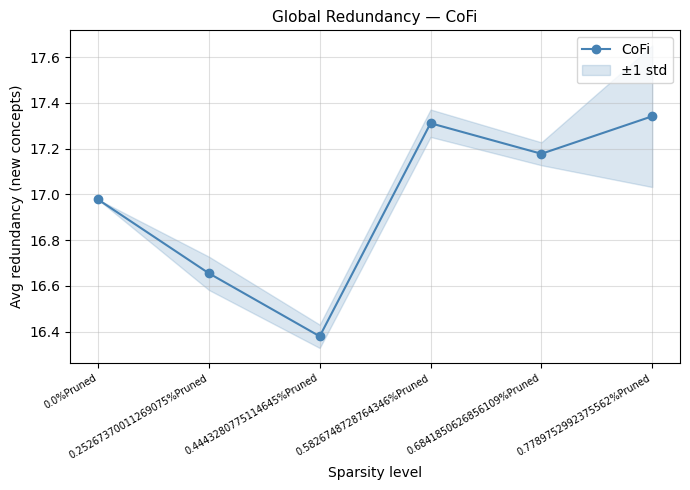

In [68]:
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

methods = ['CoFi']
global_red = defaultdict(list)

roots = ['Run0.25_5/Expls', 'Run0.25_6/Expls', 'Run0.25_7/Expls']

print("In % of the clus")
sparsity_folder = {}
for method in methods:

    # ------------------------------------------------------------------ #
    # Collect all sparsity folders (union across all roots)               #
    # ------------------------------------------------------------------ #
    sparsity_folders = set()
    for root_sub in roots:
        full_root = f'/workspace/CCE_NLI/BERT/exp/{method}/{root_sub}'
        if os.path.exists(full_root):
            sparsity_folder[root_sub] = [r for r in sorted(os.listdir(full_root)) if '.ipy' not in r]


    print(sparsity_folder)

    # per-sparsity: list over roots of that root's avg redundancy value
    # shape: {sparsity: [avg_root0, avg_root1, ...]}
    per_sparsity_root_redundancies = defaultdict(list)

    # track baseline / prev unique concepts separately per root
    unique_baseline_global_per_root = {}
    prev_global_per_root     = {}
    local_abs = {}
    for root_sub in roots:
        for i, sparsity in enumerate(sparsity_folder.get(root_sub,[])):
            print(f"\n--- {sparsity} ---")

            # baseline always comes from a fixed root
            effective_root = 'Run0.25_5/Expls' if sparsity == '0.0%Pruned' else root_sub
            full_root = f'/workspace/CCE_NLI/BERT/exp/{method}/{effective_root}/{sparsity}'
                
            if not os.path.exists(full_root):
                print(f"  Skipping {root_sub} — path not found")
                continue

            # ---------------------------------------------------------- #
            # Gather global_concepts for this (root, sparsity)            #
            # ---------------------------------------------------------- #
            global_concepts = []
            for cluster in range(1, 4):
                filepath = os.path.join(full_root, f'Cluster{cluster}IOUS1024N.csv')
                _, concepts = load_csv_data_safe(filepath)
                
                local_abstractions, _,_ = find_abstractions(concepts)
                if sparsity == '0.0%Pruned':
                    local_abs[cluster]=local_abstractions
                else:
                    print(f"Abstractions at {cluster} = {len(local_abstractions)}")
                    print(f"Alignemt = {len(set(local_abstractions) & set(local_abs[cluster]))/len(set(local_abstractions) | set(local_abs[cluster]))}")
                    
                if concepts:
                    global_concepts.extend(concepts)

            if not global_concepts:
                continue

            # ---------------------------------------------------------- #
            # Initialise / update per-root baseline tracking              #
            # ---------------------------------------------------------- #
            if '0.0%Pruned' in sparsity:
                unique_baseline_global_per_root[root_sub] = global_concepts
                prev_global_per_root[root_sub]     = global_concepts

            # concepts that are NEW at this sparsity for this root
            prev = prev_global_per_root.get(root_sub, set())
            unique_lost_global_concepts = set(unique_baseline_global_per_root[root_sub]) - set(global_concepts) 
            non_lost_concepts = set(prev) - unique_lost_global_concepts
            current_abstractions_ctr, _,_ = find_abstractions(global_concepts)
            baseline_abstractions_ctr, _,_ = find_abstractions(unique_baseline_global_per_root[root_sub])
            
            preserved_abs = set(current_abstractions_ctr.keys()) & set(baseline_abstractions_ctr.keys())
            totalcps = sum(current_abstractions_ctr.values())
          
            remaining_concepts_counter = dict(
                sorted(
                    {a: f/totalcps for a, f in current_abstractions_ctr.items() if a in preserved_abs}.items(),
                    key=lambda item: item[1],
                    reverse=True
                )
            )
            #print(remaining_concepts_counter)
           
            # redundancy among the new concepts only
            counter = Counter(
                g for g in global_concepts
            )
            
            if counter:
                #print(counter)
                root_avg = sum(counter.values()) / len(counter)
                per_sparsity_root_redundancies[i].append(root_avg)
                print(f"  {root_sub}: lost-concept avg redundancy = {root_avg:.4f}  "
                      f"(n={len(counter)} unique concepts)")
            else:
                print(f"  {root_sub}: no new concepts at this sparsity")

            # overall redundancy across all concepts (informational)
            all_counter = Counter(global_concepts)
            overall_avg = sum(all_counter.values()) / len(all_counter)
            print(f"  {root_sub}: overall avg redundancy = {overall_avg:.4f}")
            print("Number of unique concepts: ", len(counter))
            print("Number of total concepts: ", sum(all_counter.values()))
            print("Number of abstractions :", len(current_abstractions_ctr))
            print("Number of preserved abstractions: ", len(preserved_abs), 'Alignment: ', len(preserved_abs)/len(set(current_abstractions_ctr.keys()) | set(baseline_abstractions_ctr.keys())))

            # advance the per-root prev pointer
            prev_global_per_root[root_sub] = global_concepts

        # ---------------------------------------------------------------- #
        # Average across roots for this sparsity level                     #
        # ---------------------------------------------------------------- #
        root_vals = per_sparsity_root_redundancies[i]
        if root_vals:
            mean_val = float(np.mean(root_vals))
            std_val  = float(np.std(root_vals))
            print(f"  >> averaged across {len(root_vals)} root(s): "
                  f"{mean_val:.4f} ± {std_val:.4f}")
            
        else:
            mean_val = None
            print(f"  >> no data to average for {sparsity}")

    # ------------------------------------------------------------------ #
    # Build the final averaged series for plotting                        #
    # ------------------------------------------------------------------ #
    # Only include sparsity levels that had at least one root with data
    averaged_series = []
    averaged_labels = []
    std_series      = []
   
    for i in range(6):
        root_vals = per_sparsity_root_redundancies.get(i, [])
        if root_vals:
            averaged_series.append(float(np.mean(root_vals)))
            std_series.append(float(np.std(root_vals)))
            averaged_labels.append(sparsity_folder[roots[0]][i])

    global_red[method] = (averaged_labels, averaged_series, std_series)
    print(f"\nFinal averaged global redundancy for {method}:")
    for lbl, val, std in zip(averaged_labels, averaged_series, std_series):
        print(f"  {lbl}: {val:.4f} ± {std:.4f}")

# ---------------------------------------------------------------------- #
# Plot                                                                     #
# ---------------------------------------------------------------------- #
n_methods = len(methods)
fig, axes = plt.subplots(1, n_methods, figsize=(7 * n_methods, 5), sharey=True)
if n_methods == 1:
    axes = [axes]

colors = ['steelblue', 'darkorange', 'seagreen']

for ax, method, color in zip(axes, methods, colors):
    labels, vals, stds = global_red[method]
    x = range(len(vals))
    ax.plot(x, vals, marker='o', label=method, color=color)
    ax.fill_between(
        x,
        [v - s for v, s in zip(vals, stds)],
        [v + s for v, s in zip(vals, stds)],
        alpha=0.2, color=color, label='±1 std'
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
    ax.set_title(f"Global Redundancy — {method}", fontsize=11)
    ax.set_xlabel("Sparsity level")
    ax.set_ylabel("Avg redundancy (new concepts)")
    ax.legend()
    ax.grid(alpha=0.4)

plt.tight_layout()
#plt.savefig("global_redundancy_averaged.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
import matplotlib.pyplot as plt

# transpose to get 3 lines

#do concept red but instead of concepts alone get groups of concetps are save (like get infiv concepts to get groups) and couint red of groups

In [152]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts

from itertools import combinations

def get_groups(formula):
    indiv = get_indiv_concepts(formula)
    groups = []
    for length in range(2, len(indiv) + 1):
        for combo in combinations(indiv, length):
            groups.append(tuple(sorted(combo)))
    return sorted(groups)

def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = find_abstractions(get_indiv_concepts(formula))[1]
    
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    return unit_concepts, raw_concepts
#how concepts removal same across algortihm
model='BERT'
method='CoFi'
file='Run0.25_5'
root = f'/workspace/CCE_NLI/{model}/exp/{method}/{file}/Expls/'
for c in [1,2,3]:
    #print(local_concepts['0.0%Pruned'][c])
    for k in distribution:
        #print(local_concepts[k][c])
        prserved_dist = {concept:v for concept,v in local_concepts[k][c].items() if concept in local_concepts['0.0%Pruned'][c]}
        orig_preserved_dist = {concept:v for concept,v in local_concepts['0.0%Pruned'][c].items()  if concept in local_concepts[k][c]}
        
        kldiv = get_kl_divergence(local_concepts[k][c],local_concepts['0.0%Pruned'][c])
        print(f'c {c} bertlth run 5: abstractions kl div', k, kldiv)
        
        
distribution = {}
from collections import Counter
local_concepts= defaultdict(lambda : defaultdict(list))
for sparsity in os.listdir(root):
    folder_path =  os.path.join(root, sparsity)
    #if '43' in sparsity: continue
    global_concepts= defaultdict(list)
    
    for cluster in range(1,4):
        cluster_path = os.path.join(folder_path, f'Cluster{cluster}IOUS1024N.csv')
        per_neuron, all_concepts = load_csv_data(cluster_path)
        local_concepts[sparsity][cluster] = Counter(all_concepts)
        global_concepts[sparsity].extend(all_concepts)
    
    global_concepts[sparsity] = Counter(global_concepts[sparsity])
    
    total_cps= sum(list(global_concepts[sparsity].values()))
    percent_unique = len(set(global_concepts[sparsity]))/ sum(list(global_concepts[sparsity].values()))
    #convert to percent dist
    global_concepts[sparsity] = {k: freq/total_cps for k, freq in global_concepts[sparsity].items()}
    
    print(sparsity, percent_unique)
    global_concepts[sparsity] = {k: v for k, v in sorted(global_concepts[sparsity].items(), key=lambda item: item[1], reverse=True)}
    
    
    distribution[sparsity] = global_concepts[sparsity]
    #print(distribution[sparsity])
    #print(f"=========={sparsity}==============")  
    #print([f"{i}: {v}" for i,v in global_concepts[3].items() if v > 1])
    #print()
    #percent_of_overlapping_global_groups = len(baseline_groups & global_concepts) / len(global_concepts)
    #print(sparsity, 100*percent_of_overlapping_global_groups )


c 1 bertlth run 5: abstractions kl div 0.0%Pruned 0.0
c 1 bertlth run 5: abstractions kl div 0.25267370011269075%Pruned 0.42014330923557464
c 1 bertlth run 5: abstractions kl div 0.4443280775114645%Pruned 0.41927129645610195
c 1 bertlth run 5: abstractions kl div 0.5826748728764346%Pruned 0.42577910044292894
c 1 bertlth run 5: abstractions kl div 0.6841850626856109%Pruned 0.4714031156721146
c 1 bertlth run 5: abstractions kl div 0.7789752992375562%Pruned 0.4145587081487505
c 2 bertlth run 5: abstractions kl div 0.0%Pruned 0.0
c 2 bertlth run 5: abstractions kl div 0.25267370011269075%Pruned 0.5206422151740461
c 2 bertlth run 5: abstractions kl div 0.4443280775114645%Pruned 0.5344736256710553
c 2 bertlth run 5: abstractions kl div 0.5826748728764346%Pruned 0.47294031166008454
c 2 bertlth run 5: abstractions kl div 0.6841850626856109%Pruned 0.5356409427120432
c 2 bertlth run 5: abstractions kl div 0.7789752992375562%Pruned 0.5369694975622963
c 3 bertlth run 5: abstractions kl div 0.0%Pru

In [ ]:
bert lth indiv concept distribu:
    c 1 bertlth run 5: indiv concepts kl div 0.0%Pruned 0.0
    c 1 bertlth run 5: indiv concepts kl div 25.0%Pruned 0.3503017552307581
    c 1 bertlth run 5: indiv concepts kl div 43.75%Pruned 0.4744659282494067
    c 1 bertlth run 5: indiv concepts kl div 57.812%Pruned 0.35356979992229276
    c 1 bertlth run 5: indiv concepts kl div 68.359%Pruned 0.4098331306999811
    c 1 bertlth run 5: indiv concepts kl div 76.27%Pruned 0.4143401559681723
    c 2 bertlth run 5: indiv concepts kl div 0.0%Pruned 0.0
    c 2 bertlth run 5: indiv concepts kl div 25.0%Pruned 0.5009714638678757
    c 2 bertlth run 5: indiv concepts kl div 43.75%Pruned 0.6724337338185138
    c 2 bertlth run 5: indiv concepts kl div 57.812%Pruned 0.6421372494920384
    c 2 bertlth run 5: indiv concepts kl div 68.359%Pruned 0.5654016949827361
    c 2 bertlth run 5: indiv concepts kl div 76.27%Pruned 0.5227250727674763
    c 3 bertlth run 5: indiv concepts kl div 0.0%Pruned 0.0
    c 3 bertlth run 5: indiv concepts kl div 25.0%Pruned 0.7645829603133039
    c 3 bertlth run 5: indiv concepts kl div 43.75%Pruned 0.9782505564456628
    c 3 bertlth run 5: indiv concepts kl div 57.812%Pruned 1.0163705502860259
    c 3 bertlth run 5: indiv concepts kl div 68.359%Pruned 0.8865895183982936
    c 3 bertlth run 5: indiv concepts kl div 76.27%Pruned 0.9622863517979596
        
        so concpt distribution. become mro different at bigber clusters and as u prune so counts are vastly different (either dfiferent concepts and different freqs or similar concpets and dif freqs) so since iou is low 
        
        distribs are diff at high activations (more specialized)
        
        but abstractions are high iou and low kl div meaning abstractions are similar and distribus of abstractions are same too
        but indiv concepts ious low and high clusters give diff concepts within those same abstractions
        
        
bert lth abstractiun distribu
    c 1 bertlth run 5: abstractions kl div 0.0%Pruned 0.0
    c 1 bertlth run 5: abstractions kl div 25.0%Pruned 0.21386497307405267
    c 1 bertlth run 5: abstractions kl div 43.75%Pruned 0.37851502414297267
    c 1 bertlth run 5: abstractions kl div 57.812%Pruned 0.24085661263108119
    c 1 bertlth run 5: abstractions kl div 68.359%Pruned 0.2943413759755958
    c 2 bertlth run 5: abstractions kl div 0.0%Pruned 0.0
    c 2 bertlth run 5: abstractions kl div 25.0%Pruned 0.3581357015648404
    c 2 bertlth run 5: abstractions kl div 43.75%Pruned 0.3062171641801267
    c 2 bertlth run 5: abstractions kl div 57.812%Pruned 0.33624227936884843
    c 2 bertlth run 5: abstractions kl div 68.359%Pruned 0.29370231630663113
    c 3 bertlth run 5: abstractions kl div 0.0%Pruned 0.0
    c 3 bertlth run 5: abstractions kl div 25.0%Pruned 0.10869431912874405
    c 3 bertlth run 5: abstractions kl div 43.75%Pruned 0.11453963128369359
    c 3 bertlth run 5: abstractions kl div 57.812%Pruned 0.14380678980131026
    c 3 bertlth run 5: abstractions kl div 68.359%Pruned 0.17943298828211304
        
    abstractions are similar at high clus, dif at lower clus


In [153]:
spaers = sorted(list(local_concepts.keys()))
print('cluster 1')
c=1
for s in spaers[1:]:
    pres = len(set(local_concepts['0.0%Pruned'][c]) & set(local_concepts[s][c])) / len(set(local_concepts['0.0%Pruned'][c]) | set(local_concepts[s][c]))
    print(s,c ,pres, 'num cps in dense:', len(set(local_concepts['0.0%Pruned'][c])), f'num cps in {s}:', len(set(local_concepts[s][c])) ) 
spaers = list(local_concepts.keys())
c=2
print()
print('cluster 2')
for s in spaers[1:]:
    pres = len(set(local_concepts['0.0%Pruned'][c]) & set(local_concepts[s][c])) / len(set(local_concepts['0.0%Pruned'][c]) | set(local_concepts[s][c]))
    print(s,c ,pres, 'num cps in dense:', len(set(local_concepts['0.0%Pruned'][c])), f'num cps in {s}:', len(set(local_concepts[s][c])) ) 
spaers = list(local_concepts.keys())
c=3
print()
print('cluster 3')
for s in spaers[1:]:
    pres = len(set(local_concepts['0.0%Pruned'][c]) & set(local_concepts[s][c])) / len(set(local_concepts['0.0%Pruned'][c]) | set(local_concepts[s][c]))
    print(s,c ,pres, 'num cps in dense:', len(set(local_concepts['0.0%Pruned'][c])), f'num cps in {s}:', len(set(local_concepts[s][c])) ) 
print()
print('gloval 3')
for s in spaers[1:]:
    pres = len(set(distribution['0.0%Pruned']) & set(distribution[s])) / len(set(distribution['0.0%Pruned']) | set(distribution[s]))
    print(s ,pres, 'num cps in dense:', len(set(distribution['0.0%Pruned'])), f'num cps in {s}:', len(set(distribution[s])) ) 

cluster 1
0.25267370011269075%Pruned 1 0.8260869565217391 num cps in dense: 42 num cps in 0.25267370011269075%Pruned: 42
0.4443280775114645%Pruned 1 0.7551020408163265 num cps in dense: 42 num cps in 0.4443280775114645%Pruned: 44
0.5826748728764346%Pruned 1 0.7659574468085106 num cps in dense: 42 num cps in 0.5826748728764346%Pruned: 41
0.6841850626856109%Pruned 1 0.6938775510204082 num cps in dense: 42 num cps in 0.6841850626856109%Pruned: 41
0.7789752992375562%Pruned 1 0.66 num cps in dense: 42 num cps in 0.7789752992375562%Pruned: 41

cluster 2
0.25267370011269075%Pruned 2 0.7222222222222222 num cps in dense: 58 num cps in 0.25267370011269075%Pruned: 66
0.4443280775114645%Pruned 2 0.7464788732394366 num cps in dense: 58 num cps in 0.4443280775114645%Pruned: 66
0.5826748728764346%Pruned 2 0.7183098591549296 num cps in dense: 58 num cps in 0.5826748728764346%Pruned: 64
0.6841850626856109%Pruned 2 0.6756756756756757 num cps in dense: 58 num cps in 0.6841850626856109%Pruned: 66
0.778975

In [6]:
25% num cps in dense: 158 num cps in 25.0%Pruned: 154
43.75%Pruned 1 0.8291139240506329 num cps in dense: 158 num cps in 43.75%Pruned: 174
57.812%Pruned 1 0.7784810126582279 num cps in dense: 158 num cps in 57.812%Pruned: 154
68.359%Pruned 1 0.7468354430379747 num cps in dense: 158 num cps in 68.359%Pruned: 154
76.27%Pruned 1 0.7468354430379747 num cps in dense: 158 num cps in 76.27%Pruned: 161

dict_keys([1, 2, 3])

In [114]:
distribution.keys()
dis_cofi=distribution['0.0%Pruned']

In [116]:
len(set(distribution['0.0%Pruned'].keys()) & set(dis_cofi.keys()) ) / len(set(distribution['0.0%Pruned'].keys()) | set(dis_cofi.keys()) )

0.6058158319870759

In [114]:
import numpy as np
from scipy.special import kl_div

def get_kl_divergence(dist_p, dist_q, epsilon=1e-10):
    """
    KL divergence D(P || Q) between two count distributions.
    dist_p, dist_q: dicts mapping feature tuples -> counts
    """
    # Get all keys across both distributions
    all_keys = set(dist_p.keys()) | set(dist_q.keys())
    
    # Convert to arrays, filling missing keys with 0
    p = np.array([dist_p.get(k, 0) for k in all_keys], dtype=float)
    q = np.array([dist_q.get(k, 0) for k in all_keys], dtype=float)
    
    # Normalize to probabilities
    p = p / p.sum()
    q = q / q.sum()
    
    # Smooth to avoid log(0)
    p = np.where(p == 0, epsilon, p)
    q = np.where(q == 0, epsilon, q)
    
    # KL(P || Q) = sum(p * log(p/q))
    return float(np.sum(p * np.log(p / q)))



c 1 bertlth run 7: abstractions kl div 25.0%Pruned 0.41247252057641587
c 1 bertlth run 7: abstractions kl div 43.75%Pruned 0.45240103827015243
c 1 bertlth run 7: abstractions kl div 57.812%Pruned 0.4373319597493581
c 1 bertlth run 7: abstractions kl div 68.359%Pruned 0.38368147918761386
c 1 bertlth run 7: abstractions kl div 76.27%Pruned 0.28866350260006335
c 1 bertlth run 7: abstractions kl div 0.0%Pruned 0.0
c 2 bertlth run 7: abstractions kl div 25.0%Pruned 0.571647230728213
c 2 bertlth run 7: abstractions kl div 43.75%Pruned 0.5530972698754858
c 2 bertlth run 7: abstractions kl div 57.812%Pruned 0.6246813250618034
c 2 bertlth run 7: abstractions kl div 68.359%Pruned 0.5627802055926715
c 2 bertlth run 7: abstractions kl div 76.27%Pruned 0.5380153835302552
c 2 bertlth run 7: abstractions kl div 0.0%Pruned 0.0
c 3 bertlth run 7: abstractions kl div 25.0%Pruned 0.7838091208294391
c 3 bertlth run 7: abstractions kl div 43.75%Pruned 0.858135176956647
c 3 bertlth run 7: abstractions kl di

In [ ]:
clusterwise preservation
concepts alone there is high preservaiton at cluster level


run5 bertcofi: 
cluster 1
0.25267370011269075%Pruned 1 0.8368794326241135 num cps in dense: 141 num cps in 0.25267370011269075%Pruned: 154
0.4443280775114645%Pruned 1 0.8297872340425532 num cps in dense: 141 num cps in 0.4443280775114645%Pruned: 155
0.5826748728764346%Pruned 1 0.7872340425531915 num cps in dense: 141 num cps in 0.5826748728764346%Pruned: 144
0.6841850626856109%Pruned 1 0.7872340425531915 num cps in dense: 141 num cps in 0.6841850626856109%Pruned: 150
0.7789752992375562%Pruned 1 0.8014184397163121 num cps in dense: 141 num cps in 0.7789752992375562%Pruned: 148

cluster 2
0.25267370011269075%Pruned 2 0.7874396135265701 num cps in dense: 207 num cps in 0.25267370011269075%Pruned: 230
0.4443280775114645%Pruned 2 0.8019323671497585 num cps in dense: 207 num cps in 0.4443280775114645%Pruned: 234
0.5826748728764346%Pruned 2 0.7632850241545893 num cps in dense: 207 num cps in 0.5826748728764346%Pruned: 219
0.6841850626856109%Pruned 2 0.7536231884057971 num cps in dense: 207 num cps in 0.6841850626856109%Pruned: 216
0.7789752992375562%Pruned 2 0.782608695652174 num cps in dense: 207 num cps in 0.7789752992375562%Pruned: 219

cluster 3
0.25267370011269075%Pruned 3 0.7954545454545454 num cps in dense: 440 num cps in 0.25267370011269075%Pruned: 430
0.4443280775114645%Pruned 3 0.8 num cps in dense: 440 num cps in 0.4443280775114645%Pruned: 435
0.5826748728764346%Pruned 3 0.775 num cps in dense: 440 num cps in 0.5826748728764346%Pruned: 417
0.6841850626856109%Pruned 3 0.7568181818181818 num cps in dense: 440 num cps in 0.6841850626856109%Pruned: 421
0.7789752992375562%Pruned 3 0.7227272727272728 num cps in dense: 440 num cps in 0.7789752992375562%Pruned: 384
        

        
clusterwise disrtubtions
this is measuring the concepts and their frequences

c 1 bertlth run 5: abstractions kl div 0.0%Pruned 0.0
c 1 bertlth run 5: abstractions kl div 25.0%Pruned 0.21386497307405267
c 1 bertlth run 5: abstractions kl div 43.75%Pruned 0.37851502414297267
c 1 bertlth run 5: abstractions kl div 57.812%Pruned 0.24085661263108119
c 1 bertlth run 5: abstractions kl div 68.359%Pruned 0.2943413759755958
c 1 bertlth run 5: abstractions kl div 76.27%Pruned 0.3106034698341129
c 2 bertlth run 5: abstractions kl div 0.0%Pruned 0.0
c 2 bertlth run 5: abstractions kl div 25.0%Pruned 0.3581357015648404
c 2 bertlth run 5: abstractions kl div 43.75%Pruned 0.3062171641801267
c 2 bertlth run 5: abstractions kl div 57.812%Pruned 0.33624227936884843
c 2 bertlth run 5: abstractions kl div 68.359%Pruned 0.29370231630663113
c 2 bertlth run 5: abstractions kl div 76.27%Pruned 0.2748613049574955
c 3 bertlth run 5: abstractions kl div 0.0%Pruned 0.0
c 3 bertlth run 5: abstractions kl div 25.0%Pruned 0.10869431912874405
c 3 bertlth run 5: abstractions kl div 43.75%Pruned 0.11453963128369359
c 3 bertlth run 5: abstractions kl div 57.812%Pruned 0.14380678980131026
c 3 bertlth run 5: abstractions kl div 68.359%Pruned 0.17943298828211304
c 3 bertlth run 5: abstractions kl div 76.27%Pruned 0.1295877070700855

    
c 1 bertlth run 6: abstractions kl div 25.0%Pruned 0.29783550253205765
c 1 bertlth run 6: abstractions kl div 43.75%Pruned 0.3583280207146081
c 1 bertlth run 6: abstractions kl div 57.813%Pruned 0.3035880413679879
c 1 bertlth run 6: abstractions kl div 68.359%Pruned 0.2997243464860887
c 1 bertlth run 6: abstractions kl div 76.27%Pruned 0.16341130615673372
c 1 bertlth run 6: abstractions kl div 0.0%Pruned 0.0
c 2 bertlth run 6: abstractions kl div 25.0%Pruned 0.36276767747827204
c 2 bertlth run 6: abstractions kl div 43.75%Pruned 0.14978781737930402
c 2 bertlth run 6: abstractions kl div 57.813%Pruned 0.24169225002928568
c 2 bertlth run 6: abstractions kl div 68.359%Pruned 0.14121685094231154
c 2 bertlth run 6: abstractions kl div 76.27%Pruned 0.24437953792482542
c 2 bertlth run 6: abstractions kl div 0.0%Pruned 0.0
c 3 bertlth run 6: abstractions kl div 25.0%Pruned 0.09989016157672827
c 3 bertlth run 6: abstractions kl div 43.75%Pruned 0.09914167637987523
c 3 bertlth run 6: abstractions kl div 57.813%Pruned 0.11755910690232287
c 3 bertlth run 6: abstractions kl div 68.359%Pruned 0.08550880200986896
c 3 bertlth run 6: abstractions kl div 76.27%Pruned 0.14786848466834673
c 3 bertlth run 6: abstractions kl div 0.0%Pruned 0.0
    
c 1 bertlth run 7: abstractions kl div 25.0%Pruned 0.3212609525408718
c 1 bertlth run 7: abstractions kl div 43.75%Pruned 0.3075866387965402
c 1 bertlth run 7: abstractions kl div 57.812%Pruned 0.2926643403709689
c 1 bertlth run 7: abstractions kl div 68.359%Pruned 0.3010929483061494
c 1 bertlth run 7: abstractions kl div 76.27%Pruned 0.20954979378292019
c 1 bertlth run 7: abstractions kl div 0.0%Pruned 0.0
c 2 bertlth run 7: abstractions kl div 25.0%Pruned 0.3231822913844155
c 2 bertlth run 7: abstractions kl div 43.75%Pruned 0.2558327062062159
c 2 bertlth run 7: abstractions kl div 57.812%Pruned 0.305206364325861
c 2 bertlth run 7: abstractions kl div 68.359%Pruned 0.2668527084210674
c 2 bertlth run 7: abstractions kl div 76.27%Pruned 0.25350910295117596
c 2 bertlth run 7: abstractions kl div 0.0%Pruned 0.0
c 3 bertlth run 7: abstractions kl div 25.0%Pruned 0.08580196078058688
c 3 bertlth run 7: abstractions kl div 43.75%Pruned 0.14577245002760852
c 3 bertlth run 7: abstractions kl div 57.812%Pruned 0.14019823874421566
c 3 bertlth run 7: abstractions kl div 68.359%Pruned 0.17102303426230125
c 3 bertlth run 7: abstractions kl div 76.27%Pruned 0.16135012726619033
c 3 bertlth run 7: abstractions kl div 0.0%Pruned 0.0

In [80]:
hashmap_dist = {}
for grouping in distribution['25.0%Pruned']:
    hashmap_dist[grouping] = 1
for grouping in distribution['0.0%Pruned']:
    if not hashmap_dist.get(grouping, 0):
        for cluster in range(1,4):
            for group in local_concepts['0.0%Pruned'][cluster]:
                if sorted(group) ==  sorted(grouping):
                    print(group, grouping, cluster)
               
        
        

('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('pre:tag:jj', 'pre:tag:vbz') ('pre:tag:jj', 'pre:tag:vbz') 1
('oth:overlap:overlap25', 'pre:tag:jj', 'pre:tag:vbz') ('oth:overlap:overlap25', 'pre:tag:jj', 'pre:tag:vbz') 1
('oth:overlap:overlap25', 'pre:tag:jj', 'pre:tag:vbz') ('oth:overlap:overlap25', 'pre:tag:jj', 'pre:tag:vbz') 1
('oth:overlap:overlap25', 'pre:tag:jj', 'pre:tag:vbz') ('oth:overlap:overlap25', 'pre:tag:jj', 'pre:tag:vbz') 1
('oth:overlap:overlap25', 'pre:tag:jj', 'pre

In [75]:
for grouping in distribution['25.0%Pruned']:
    for i in ('pre:tag:jj', 'pre:tag:vbz'):
        if i in grouping and len(grouping)==2:
            print(grouping)

('oth:overlap:overlap25', 'pre:tag:jj')
('oth:overlap:overlap50', 'pre:tag:jj')
('hyp:tok:for', 'pre:tag:jj')
('hyp:tok:outside', 'pre:tag:jj')
('hyp:tok:to', 'pre:tag:jj')
('pre:tag:jj', 'pre:tag:nnp')
('pre:tag:jj', 'pre:tok:man')
('hyp:tok:people', 'pre:tag:jj')
('hyp:tag:nn', 'pre:tag:jj')
('hyp:tag:dt', 'pre:tag:jj')
('hyp:tag:prp$', 'pre:tag:jj')
('pre:tag:jj', 'pre:tok:woman')
('pre:tag:jj', 'pre:tag:prp$')
('hyp:tag:in', 'pre:tag:jj')
('pre:tag:jj', 'pre:tag:nn')
('pre:tag:,', 'pre:tag:jj')
('hyp:tag:ex', 'pre:tag:jj')
('pre:tag:in', 'pre:tag:jj')
('hyp:tok:woman', 'pre:tag:jj')
('pre:tag:jj', 'pre:tok:sitting')
('pre:tag:jj', 'pre:tok:walking')
('pre:tag:cc', 'pre:tag:jj')
('hyp:tok:playing', 'pre:tag:jj')
('hyp:tok:is', 'pre:tag:jj')
('oth:overlap:overlap75', 'pre:tag:jj')
('pre:tag:jj', 'pre:tok:while')
('hyp:tok:man', 'pre:tag:jj')
('hyp:tok:there', 'pre:tag:jj')
('pre:tag:jj', 'pre:tok:and')
('hyp:tag:nn', 'pre:tag:vbz')
('hyp:tag:vbg', 'pre:tag:jj')
('oth:overlap:overlap2

## Tracking explainable nueron count

In [ ]:

def load_neuron_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    explainable_units = []
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        explainable_units.append(unit)
        
    
    return explainable_units
base = '/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls/'
tracking_expl_units= defaultdict(lambda: defaultdict())
for sparsity in os.listdir(base):
    try:
    
        sparsity = float(sparsity.split("%")[0])
    except:
        continue
    for cluster in ['Cluster1IOUS1024N.csv', 'Cluster2IOUS1024N.csv', 'Cluster3IOUS1024N.csv']:
        filepath = os.path.join(base, f'{sparsity}%Pruned', cluster)
      
        try:
            explble_units = load_neuron_data(filepath)
            tracking_expl_units[str(sparsity)][cluster] = len(explble_units)
        except:
            continue
        
        
tracking_expl_units

## Net gain in func non func concepts per sparsity cluster wise and how it affects number and % of func and non func

In [ ]:
#clusterwise but not unique to each cluster
#cluster wise
import os

base_dir = "/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls/"

cluster_files = [
    "Cluster1IOUS1024N.csv",
    "Cluster2IOUS1024N.csv",
    "Cluster3IOUS1024N.csv",
]

critical_tokens = [
    "a", "an", "the", "this", "that", "these", "those",
    "some", "any", "each", "every", "no",
    "i", "you", "he", "she", "it", "they",
    "me", "him", "her", "them",
    "his", "hers", "their", "its",
    "someone", "something", "nobody",
    "in", "on", "at", "by", "for", "from", "to", "with",
    "about", "into", "through", "over", "under",
    "between", "near", "inside", "outside",
    "and", "or", "but", "because", "while", "if", "though", "although", "so",
    "is", "am", "are", "was", "were", "be", "being", "been",
    "do", "does", "did",
    "have", "has", "had",
    "can", "could", "will", "would", "should", "may", "might", "must",
    "not", "none", "never", "nothing", "least", "most", "all",
    "there", "here", "just", "only", "also", "very",
    ".", ",", ":", ";", "!", "?"
]

def label_concept(concept: str):
    """Return 'c' for critical or 'nc' for non-critical"""
    if ":tag:" in concept:
        return "c"
    if concept.startswith("oth:"):
        return "c"
    if ":tok:" in concept:
        token = concept.split(":tok:")[-1]
        return "c" if token in critical_tokens else "nc"
    return "nc"

def load_cluster_concepts(sparsity_dir, cluster_file):
    """Load concepts from a single cluster CSV"""
    try:
        
        unit_concepts = load_csv_data(os.path.join(sparsity_dir, cluster_file))
       
        all_concepts = set()
        for concepts in unit_concepts.values():
            all_concepts.update(concepts)
        return all_concepts
    except Exception:
        return set()

# Load concepts per cluster per sparsity
sparsity_to_cluster_concepts = {}  # sparsity -> cluster -> set(concepts)

for sparsity in os.listdir(base_dir):
    sparsity_path = os.path.join(base_dir, sparsity)
    
    try:
        s = float(sparsity.split("%")[0])
   
    except ValueError:
        continue

    cluster_concepts = {}
    for i, fname in enumerate(cluster_files, 1):
        cluster_name = f"c{i}"
        concepts = load_cluster_concepts(sparsity_path, fname)
        cluster_concepts[cluster_name] = concepts
    

    sparsity_to_cluster_concepts[s] = cluster_concepts
    total = sum(len(c) for c in cluster_concepts.values())
    print(f"Sparsity {s}: {total} total concepts across clusters")

# Track added/removed functional concepts per cluster between sparsity steps
removed_concepts_by_step = {}
added_concepts_by_step = {}

sparsities = sorted(sparsity_to_cluster_concepts.keys())
for i in range(-1, len(sparsities) - 1):
    s_prev, s_next = sparsities[0], sparsities[i + 1]

    print(f"\nSparsity {s_prev} → {s_next}")

    for cluster in cluster_files:
        c_name = f"c{cluster_files.index(cluster) + 1}"
        prev = sparsity_to_cluster_concepts[s_prev][c_name]
        next_ = sparsity_to_cluster_concepts[s_next][c_name]

        removed = prev - next_
        added = next_ - prev

        removed_func = sum(1 for c in removed if label_concept(c) == 'c')
        added_func = sum(1 for c in added if label_concept(c) == 'c')

        print(f"\nCluster {c_name}:")
        #print(f"  Removed concepts: {len(removed)} (Functional: {removed_func}): {removed}")
        #print(f"  Added concepts:   {len(added)} (Functional: {added_func}): {added}")
        #print(f"  Prev Total concepts:   {len(prev)}")
        print(f"  Next concepts:   {next_}")
        
        new_func = sum(1 for c in next_ if label_concept(c) == 'c')
        if len(next_) >0:
            #print(f"  % of func:   {new_func}/{len(next_)} = {new_func/len(next_)}")
            #print(f"  % of non func:   {len(next_) - new_func}/{len(next_)} = {1 - (new_func/len(next_))}")
            pass

        removed_concepts_by_step[(s_prev, s_next, c_name)] = removed
        added_concepts_by_step[(s_prev, s_next, c_name)] = added


## net gain in number and % of func and non func unique to a cluster and how that changes func and nonfunc distribution

In [ ]:
#cluster wise
import os

base_dir = "/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls/"

cluster_files = [
    "Cluster1IOUS1024N.csv",
    "Cluster2IOUS1024N.csv",
    "Cluster3IOUS1024N.csv",
]

critical_tokens = [
    "a", "an", "the", "this", "that", "these", "those",
    "some", "any", "each", "every", "no",
    "i", "you", "he", "she", "it", "they",
    "me", "him", "her", "them",
    "his", "hers", "their", "its",
    "someone", "something", "nobody",
    "in", "on", "at", "by", "for", "from", "to", "with",
    "about", "into", "through", "over", "under",
    "between", "near", "inside", "outside",
    "and", "or", "but", "because", "while", "if", "though", "although", "so",
    "is", "am", "are", "was", "were", "be", "being", "been",
    "do", "does", "did",
    "have", "has", "had",
    "can", "could", "will", "would", "should", "may", "might", "must",
    "not", "none", "never", "nothing", "least", "most", "all",
    "there", "here", "just", "only", "also", "very",
    ".", ",", ":", ";", "!", "?"
]

def label_concept(concept: str):
    """Return 'c' for critical or 'nc' for non-critical"""
    if ":tag:" in concept:
        return "c"
    if concept.startswith("oth:"):
        return "c"
    if ":tok:" in concept:
        token = concept.split(":tok:")[-1]
        return "c" if token in critical_tokens else "nc"
    return "nc"

def load_cluster_concepts(sparsity_dir, cluster_file):
    """Load concepts from a single cluster CSV"""
    try:
        unit_concepts = load_csv_data(os.path.join(sparsity_dir, cluster_file))
        all_concepts = set()
        for concepts in unit_concepts.values():
            all_concepts.update(concepts)
        return all_concepts
    except Exception:
        return set()

# Load concepts per cluster per sparsity
sparsity_to_cluster_concepts_unique = {}  # sparsity -> cluster -> set(concepts)

for sparsity in os.listdir(base_dir):
    sparsity_path = os.path.join(base_dir, sparsity)
    try:
        s = float(sparsity.split("%")[0])
    except ValueError:
        continue

    cluster_concepts = {}
    for i, fname in enumerate(cluster_files, 1):
        cluster_name = f"c{i}"
        concepts = load_cluster_concepts(sparsity_path, fname)
        cluster_concepts[cluster_name] = concepts
    
    c1o = cluster_concepts['c1']  - cluster_concepts['c2'] - cluster_concepts['c3']  
    c2o = cluster_concepts['c2']  - cluster_concepts['c1'] - cluster_concepts['c3']  
    c3o = cluster_concepts['c3']  - cluster_concepts['c1'] - cluster_concepts['c2']  
    cluster_concepts['c1']=c1o
    cluster_concepts['c2']=c2o
    cluster_concepts['c3']=c3o
    sparsity_to_cluster_concepts_unique[s] = cluster_concepts
    total = sum(len(c) for c in cluster_concepts.values())
    print(f"Sparsity {s}: {total} total concepts across clusters")

# Track added/removed functional concepts per cluster between sparsity steps
removed_concepts_by_step = {}
added_concepts_by_step = {}

sparsities = sorted(sparsity_to_cluster_concepts_unique.keys())
for i in range(-1, len(sparsities) - 1):
    s_prev, s_next = sparsities[0], sparsities[i + 1]

    print(f"\nSparsity {s_prev} → {s_next}")

    for cluster in cluster_files:
        c_name = f"c{cluster_files.index(cluster) + 1}"
        prev = sparsity_to_cluster_concepts_unique[s_prev][c_name]
        next_ = sparsity_to_cluster_concepts_unique[s_next][c_name]

        removed = prev - next_
        added = next_ - prev

        removed_func = sum(1 for c in removed if label_concept(c) == 'c')
        added_func = sum(1 for c in added if label_concept(c) == 'c')

        print(f"\nCluster {c_name}:")
        print(f"  Removed concepts: {len(removed)} (Functional: {removed_func})")
        print(f"  Added concepts:   {len(added)} (Functional: {added_func})")
        print(f"  Prev Total concepts:   {len(prev)}")
        print(f"  Next Total concepts:   {len(next_)}")
        
        new_func = sum(1 for c in next_ if label_concept(c) == 'c')
        print(f"  % of func:   {new_func}/{len(next_)} = {new_func/len(next_)}")
        print(f"  % of non func:   {len(next_) - new_func}/{len(next_)} = {1 - (new_func/len(next_))}")

        removed_concepts_by_step[(s_prev, s_next, c_name)] = removed
        added_concepts_by_step[(s_prev, s_next, c_name)] = added


## Plotting % and number of concepts (unique to cluster and cluster-wise)

In [ ]:
import matplotlib.pyplot as plt

def plot_func_percentages(sparsity_to_cluster_concepts, unique=False):
    """
    Plot percent of functional concepts per cluster vs sparsity.

    Parameters:
    - sparsity_to_cluster_concepts: dict[sparsity -> cluster -> set(concepts)]
    - unique: if True, counts only concepts unique to that cluster
    """
    sparsities = sorted(sparsity_to_cluster_concepts.keys())
    clusters = ['c1', 'c2', 'c3']

    # Prepare data for plotting
    func_percent = {c: [] for c in clusters}

    for s in sparsities:
        if s > 0.6: continue
        cluster_concepts = sparsity_to_cluster_concepts[s]

        # If unique=True, remove concepts that appear in other clusters at same sparsity
        if unique:
            all_concepts = set().union(*cluster_concepts.values())
            unique_concepts = {}
            for c in clusters:
                others = all_concepts - cluster_concepts[c]
                unique_concepts[c] = cluster_concepts[c] - others
            cluster_concepts = unique_concepts

        for c in clusters:
            concepts = cluster_concepts[c]
            if len(concepts) == 0:
                pct = 0
            else:
                func_count = sum(1 for x in concepts if label_concept(x) == 'c')
                pct = func_count / len(concepts)
            func_percent[c].append(pct * 100)  # convert to %
    
    # Plot
    plt.figure(figsize=(8,6))
    for c in clusters:
        plt.plot(sparsities[:-2], func_percent[c], marker='o', label=f"{c}")
    plt.xlabel("Sparsity")
    plt.ylabel("% Functional Concepts")
    title = "Percent of Functional Concepts per Cluster"
    if unique:
        title += " (Unique to Cluster)"
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
plot_func_percentages(sparsity_to_cluster_concepts_unique, unique=True)
plot_func_percentages(sparsity_to_cluster_concepts, unique=False)


these graphs say that: overall, pruning induces more generality in the final layer, but nonfunc concepts still become more prevalent at c3

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_func_vs_total_grid(sparsity_to_cluster_concepts, unique=False):
    """
    Plot 4 subplots in a 1-row, 4-column grid showing functional vs total concepts per cluster,
    with numbers on top.
    
    Parameters:
    - sparsity_to_cluster_concepts: dict[sparsity -> cluster -> set(concepts)]
    - unique: if True, counts only concepts unique to that cluster
    """
    sparsities = sorted(sparsity_to_cluster_concepts.keys())[:4]  # pick first 4 sparsities
    clusters = ['c1', 'c2', 'c3']
    n_clusters = len(clusters)
    width = 0.35
    
    # 1 row, 4 columns
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    
    for i, s in enumerate(sparsities):
        ax = axes[i]
        
        cluster_concepts = sparsity_to_cluster_concepts[s]
        
        # Unique-to-cluster filter
        if unique:
            all_concepts = set().union(*cluster_concepts.values())
            unique_concepts = {}
            for c in clusters:
                others = all_concepts - cluster_concepts[c]
                unique_concepts[c] = cluster_concepts[c] - others
            cluster_concepts = unique_concepts
        
        func_counts = []
        total_counts = []
        for c in clusters:
            concepts = cluster_concepts[c]
            total_counts.append(len(concepts))
            func_counts.append(sum(1 for x in concepts if label_concept(x) == 'c'))
        
        x = np.arange(n_clusters)
        bars_func = ax.bar(x - width/2, func_counts, width, label='Functional', color='skyblue')
        bars_total = ax.bar(x + width/2, total_counts, width, label='Total', color='orange')
        
        # Numbers on top
        for bar in bars_func + bars_total:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)
        
        ax.set_xticks(x)
        ax.set_xticklabels(clusters)
        ax.set_xlabel("Cluster")
        ax.set_title(f"Sparsity {s}")
        ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    axes[0].set_ylabel("Number of Concepts")
    fig.suptitle("Functional vs Total Concepts per Cluster", fontsize=16)
    fig.legend(['Functional', 'Total'], loc='upper right')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Call the function
plot_func_vs_total_grid(sparsity_to_cluster_concepts, unique=False)
plot_func_vs_total_grid(sparsity_to_cluster_concepts_unique, unique=True)

## Concept redundancy func vs non func number wise (AVG concept redundancy)

In [ ]:
import os
from collections import defaultdict, Counter

def load_cluster_concepts_from_csv(sparsity_dir):
    """
    Load concepts for c1, c2, c3 from CSVs in a given sparsity folder.
    Returns dict: cluster_name -> list(concepts)
    """
    cluster_files = [
        "Cluster1IOUS1024N.csv",
        "Cluster2IOUS1024N.csv",
        "Cluster3IOUS1024N.csv",
    ]
    cluster_concepts = {}
    for i, fname in enumerate(cluster_files, start=1):
        fpath = os.path.join(sparsity_dir, fname)
        try:
            unit_concepts = load_csv_data(fpath)  # your function: unit -> set(concepts)
            all_concepts = []
            for concepts in unit_concepts.values():
                all_concepts.extend(concepts)
            cluster_concepts[f'c{i}'] = all_concepts
        except Exception as e:
            print(f"Failed to load {fpath}: {e}")
            cluster_concepts[f'c{i}'] = []
    return cluster_concepts

def compute_func_nonfunc_redundancy(base_dir):
    """
    Load CSVs for each sparsity and cluster, compute average redundancy for functional vs non-functional concepts.
    
    Returns:
    - redundancy_stats[sparsity][cluster] = {
        'func_total': number of unique functional concepts,
        'func_avg_redundancy': average times each functional concept appears across clusters,
        'nonfunc_total': number of unique non-functional concepts,
        'nonfunc_avg_redundancy': average times each non-functional concept appears across clusters
      }
    """
    redundancy_stats = {}

    for sparsity in os.listdir(base_dir):
        sparsity_path = os.path.join(base_dir, sparsity)
        try:
            s = float(sparsity.split("%")[0])
            if s >0.6: continue
        except ValueError:
            continue

        cluster_concepts = load_cluster_concepts_from_csv(sparsity_path)
        redundancy_stats[s] = {}

        # Flatten all concepts across clusters to count redundancy
        all_concepts = []
        for concepts in cluster_concepts.values():
            all_concepts.extend(concepts)
        concept_counts = Counter(all_concepts)  # counts across all clusters

        for cluster_name, concepts in cluster_concepts.items():
            unique_func = set(c for c in concepts if label_concept(c) == 'c')
            unique_nonfunc = set(c for c in concepts if label_concept(c) != 'c')

            func_avg_redundancy = (sum(concept_counts[c] for c in unique_func) / len(unique_func)) if unique_func else 0
            nonfunc_avg_redundancy = (sum(concept_counts[c] for c in unique_nonfunc) / len(unique_nonfunc)) if unique_nonfunc else 0

            redundancy_stats[s][cluster_name] = {
                #'func_total': len(unique_func),
                'func_avg_redundancy': func_avg_redundancy,
                #'nonfunc_total': len(unique_nonfunc),
                'nonfunc_avg_redundancy': nonfunc_avg_redundancy
            }

    return redundancy_stats


redundancy_stats=compute_func_nonfunc_redundancy(base_dir)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_func_nonfunc_avg_redundancy(redundancy_stats):
    """
    Plot bar plots of average redundancy for functional vs non-functional concepts.
    
    Parameters:
    - redundancy_stats[sparsity][cluster] -> dict with 'func_avg_redundancy' and 'nonfunc_avg_redundancy'
    """
    sparsities = sorted(redundancy_stats.keys())[:4]  # first 4 sparsities
    clusters = ['c1', 'c2', 'c3']
    n_clusters = len(clusters)
    width = 0.35

    fig, axes = plt.subplots(1, 4, figsize=(20,5), sharey=True)
    axes = np.expand_dims(axes, axis=0)  # make axes[0][i] style

    for i, s in enumerate(sparsities):
        ax = axes[0][i]

        func_avg = [redundancy_stats[s][c]['func_avg_redundancy'] for c in clusters]
        nonfunc_avg = [redundancy_stats[s][c]['nonfunc_avg_redundancy'] for c in clusters]

        x = np.arange(n_clusters)
        bars_func = ax.bar(x - width/2, func_avg, width, color='skyblue', label='Functional')
        bars_nonfunc = ax.bar(x + width/2, nonfunc_avg, width, color='orange', label='Non-Functional')

        # Annotate numbers on top of bars
        for bar in bars_func + bars_nonfunc:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.2f}',
                    ha='center', va='bottom', fontsize=10)

        ax.set_xticks(x)
        ax.set_xticklabels(clusters)
        ax.set_xlabel("Cluster")
        ax.set_title(f"Sparsity {s}")
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    axes[0][0].set_ylabel("Average Redundancy")
    fig.suptitle("Average Redundancy of Functional vs Non-Functional Concepts", fontsize=16)
    fig.legend(['Functional', 'Non-Functional'], loc='upper right')
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
plot_func_nonfunc_avg_redundancy(redundancy_stats)

In [ ]:
concepts_by_cluster = collect_concepts_per_neuron_by_cluster(base_dir='/workspace/CCE_NLI/BERT/exp/')
def get_pis(root):
    pis =[]
    i=0
    for fldername in sorted(os.listdir(root)):
        print(fldername)
        try:
            pis.append(float(fldername.split("%")[0]))
            i+=1
        except:
            continue
    return pis

pis = get_pis(root='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls')
def neuron_count_table(concepts_by_cluster):
    """
    Input:
      concepts_by_cluster[method][prune_pct][cluster_id][neuron] = set(concepts)

    Output:
      pandas DataFrame with rows = sparsity levels,
      columns = methods (cofi, lottery_ticket, wanda),
      values = "c1:10 c2:5 c3:1"
    """
    rows = defaultdict(dict)
    
    finallay_neurons =[1024,1022,1022,1022,1020]
    totals={pi:fn for pi,fn in zip(pis, finallay_neurons)}
    #totals={0.0: 1024,0.25:768, 0.4404:573, 0.579: 431, 0.6884:319, 0.7695:256}
    print(totals)
    for method, method_data in concepts_by_cluster.items():
        if method in ['lottery_ticket', 'wanda']:
            total=1024
        for prune_pct, prune_data in method_data.items():
            cluster_counts = []


            if method not in ['lottery_ticket', 'wanda']:
                total = totals[prune_pct]

            for cluster_id, neuron_map in prune_data.items():
                # extract cluster number (Cluster1, Cluster2, ...)
                m = re.search(r"Cluster(\d+)", cluster_id)
                cluster_name = f"c{m.group(1)}" if m else cluster_id

                n_neurons = len(neuron_map)
                cluster_counts.append(f"{cluster_name}:{100*n_neurons/total}")

            # sort c1, c2, c3
            cluster_counts = sorted(
                cluster_counts,
                key=lambda x: int(re.search(r"\d+", x).group())
            )
            print(f"prune_pct: {prune_pct} \t cluster counts: {cluster_counts}")
            rows[prune_pct][method] = " ".join(cluster_counts)

    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index.name = "sparsity"
    df = df.sort_index()

    return df
neuron_count_table(concepts_by_cluster)

In [ ]:
#bowman becomes signficantly more explainable (2% to 23% neurons explainable vs 1.6% to 4.2% or 3.2%) with cofi pruning over lth, wanda

## % and nunmber of functional concepts per cluster, globally, and unique to cluster at each sparsity

In [ ]:
def collect_cluster_concepts_at_sparsity(
    concepts_by_cluster,
    method='lottery_ticket',
    sparsity=0.25,
    cluster_num=3
):
    """
    Returns:
        set of all unique concepts in Cluster{cluster_num}
        for a given sparsity across all neurons
    """
    cluster_key = f"Cluster{cluster_num}"
    all_concepts = set()

    # Get only the requested sparsity
    clusters_at_sparsity = concepts_by_cluster.get(method, {}).get(sparsity, {})

    for cluster_id, neuron_map in clusters_at_sparsity.items():
        if not cluster_id.startswith(cluster_key):
            continue

        for neuron, concepts in neuron_map.items():
            all_concepts.update(concepts)

    return all_concepts
c1_percentfunctional =[]
c2_percentfunctional =[]
c3_percentfunctional =[]
global_func=[]
lenall=[]
funcs=[]
nfuncs=[]
for sp in pis:
    try:
        c3 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp, method='CoFi', cluster_num=3)
        c2 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp,method='CoFi', cluster_num=2)
        c1 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp, method='CoFi', cluster_num=1)
        all_cps_fl = set(c1).union(set(c2)).union(set(c3))
        c,nc, _ = annotate_concepts(all_cps_fl)
        funcs.append(c)
        nfuncs.append(nc)
        onlyc1=set(c1)-set(c2)-set(c3)
        onlyc2=set(c2)-set(c1)-set(c3)
        onlyc3=set(c3)-set(c1)-set(c2)
        c1n,nc1, _ = annotate_concepts(c1)
        c1_percentfunctional.append(100*c1n/(c1n+nc1))
        c2n,nc2, _ = annotate_concepts(c2)
        c2_percentfunctional.append(100*c2n/(c2n+nc2))

        c3n,nc3, _ = annotate_concepts(c3)
        c3_percentfunctional.append(100*c3n/(c3n+nc3))
        lenall.append(len(all_cps_fl))
        global_func.append(100*c/(c+nc))
        print(f'Sparsity {sp}, Percent of foundational concepts in c1 : {100*c1n/(c1n+nc1)}% calculated on {len(set(onlyc1))} concepts')    
        print(f'Sparsity {sp}, Percent of foundational concepts in c2: {100*c2n/(c2n+nc2)}% calculated on {len(set(onlyc2))} concepts')    
        print(f'Sparsity {sp}, Percent of foundational concepts in c3: {100*c3n/(c3n+nc3)}% calculated on {len(set(onlyc3))} concepts')    
        print(f'Sparsity {sp}, Percent of foundational concepts globally : {100*c/(c+nc)}% calculated on {len(set(all_cps_fl))} concepts')
    except:
        continue
        
        
import matplotlib.pyplot as plt

# line plot plotting % of functional concepts
plt.figure(figsize=(6,4))

# Line + points
plt.plot(pis[:4], global_func[:4], marker='o', linewidth=2, label='Functional %')

# Annotate values on points
for x, y in zip(pis[:4], global_func[:4]):
    plt.text(x, y + 0.3, f"{y:.2f}%", ha='center', fontsize=10)

# Labels and title
plt.xlabel("Sparsity")
plt.ylabel("Percent of Functional Concepts")
plt.title("% of Functional Concepts Globally")

# Grid + legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# line plot plotting number functional concepts
plt.figure(figsize=(6,4))

# Line + points
plt.plot(pis[:4], lenall[:4], marker='o', linewidth=2, label='Functional %')

# Annotate values on points
for x, y in zip(pis[:4], lenall[:4]):
    plt.text(x, y + 0.3, f"{y:.2f}", ha='center', fontsize=10)

# Labels and title
plt.xlabel("Sparsity")
plt.ylabel("Number of Functional Concepts")
plt.title("Number of unique concepts Globally")

# Grid + legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


#bar plot counting number of func and nonfunc concepts per sparisty (across all clusters ie globaly)
import matplotlib.pyplot as plt
import numpy as np

# Data
x = np.arange(len(pis[:4]))
width = 0.35

plt.figure(figsize=(7,4))

bars_func = plt.bar(x - width/2, funcs[:4], width, label='Functional')
bars_nonfunc = plt.bar(x + width/2, nfuncs[:4], width, label='Non-Functional')

# Annotate values on bars
for bars in [bars_func, bars_nonfunc]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f"{height:.2f}",
                 ha='center',
                 va='bottom',
                 fontsize=10)

# Axes & labels
plt.xticks(x, pis[:4])
plt.xlabel("Sparsity")
plt.ylabel("Value")
plt.title("Functional vs Non-Functional Concepts")

# Grid + legend
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
concept_counts_by_sparsity(concepts_by_cluster, method="wanda", cluster_num=1)

In [ ]:
concept_counts_by_sparsity(concepts_by_cluster, method="wanda", cluster_num=2)

In [ ]:
concept_counts_by_sparsity(concepts_by_cluster, method="wanda", cluster_num=3)

In [ ]:
concept_counts_by_sparsity(concepts_by_cluster, method="wanda", cluster_num=3, global_=True)

In [ ]:
critical_tokens =  [
    "a", "an", "the", "this", "that", "these", "those",
    "some", "any", "each", "every", "no",
    "i", "you", "he", "she", "it", "they",
    "me", "him", "her", "them",
    "his", "hers", "their", "its",
    "someone", "something", "nobody",
    "in", "on", "at", "by", "for", "from", "to", "with",
    "about", "into", "through", "over", "under",
    "between", "near", "inside", "outside",
    "and", "or", "but", "because", "while", "if", "though", "although", "so",
    "is", "am", "are", "was", "were", "be", "being", "been",
    "do", "does", "did",
    "have", "has", "had",
    "can", "could", "will", "would", "should", "may", "might", "must",
    "not", "none", "never", "nothing", "least", "most", "all",
    "there", "here", "just", "only", "also", "very",
    ".", ",", ":", ";", "!", "?"
]


def label_concept(concept: str):
    """
    Returns 'c' for critical or 'nc' for non-critical
    """
    # POS tags are always critical
    if ":tag:" in concept:
        return "c"

    # Overlap / structural features
    if concept.startswith("oth:"):
        return "c"

    # Token-level concepts
    if ":tok:" in concept:
        token = concept.split(":tok:")[-1]
        return "c" if token in critical_tokens else "nc"

    # Default fallback
    return "nc"


def annotate_concepts(concept_set):
    annotated = {}
    num_critical = 0
    num_noncritical = 0

    for concept in sorted(concept_set):
        label = label_concept(concept)
        annotated[concept] = label

        if label == "c":
            num_critical += 1
        else:
            num_noncritical += 1


    return num_critical, num_noncritical, annotated

annotate_concepts(all_cps_fl)

In [ ]:
def collect_cluster_concepts_at_sparsity(
    concepts_by_cluster,
    method='lottery_ticket',
    sparsity=0.25,
    cluster_num=3
):
    """
    Returns:
        set of all unique concepts in Cluster{cluster_num}
        for a given sparsity across all neurons
    """
    cluster_key = f"Cluster{cluster_num}"
    all_concepts = set()

    # Get only the requested sparsity
    clusters_at_sparsity = concepts_by_cluster.get(method, {}).get(sparsity, {})

    for cluster_id, neuron_map in clusters_at_sparsity.items():
        if not cluster_id.startswith(cluster_key):
            continue

        for neuron, concepts in neuron_map.items():
            all_concepts.update(concepts)

    return all_concepts
c1_percentfunctional =[]
c2_percentfunctional =[]
c3_percentfunctional =[]
global_func=[]
for sp in pis:
    c3 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp, method='CoFi', cluster_num=3)
    c2 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp,method='CoFi', cluster_num=2)
    c1 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp, method='CoFi', cluster_num=1)
    all_cps_fl = set(c1).union(set(c2)).union(set(c3))
    c,nc, _ = annotate_concepts(all_cps_fl)
    onlyc1=set(c1)-set(c2)-set(c3)
    onlyc2=set(c2)-set(c1)-set(c3)
    onlyc3=set(c3)-set(c1)-set(c2)
    c1n,nc1, _ = annotate_concepts(c1)
    c1_percentfunctional.append(100*c1n/(c1n+nc1))
    c2n,nc2, _ = annotate_concepts(c2)
    c2_percentfunctional.append(100*c2n/(c2n+nc2))
    
    c3n,nc3, _ = annotate_concepts(c3)
    c3_percentfunctional.append(100*c3n/(c3n+nc3))
    
    global_func.append(100*c/(c+nc))
    print(f'Sparsity {sp}, Percent of foundational concepts in c1 : {100*c1n/(c1n+nc1)}% calculated on {len(set(c1))} concepts')    
    print(f'Sparsity {sp}, Percent of foundational concepts in c2: {100*c2n/(c2n+nc2)}% calculated on {len(set(c2))} concepts')    
    print(f'Sparsity {sp}, Percent of foundational concepts in c3: {100*c3n/(c3n+nc3)}% calculated on {len(set(c3))} concepts')    
    print(f'Sparsity {sp}, Percent of foundational concepts globally : {100*c/(c+nc)}% calculated on {len(set(all_cps_fl))} concepts')
    


In [ ]:
c1_percentfunctional
c2_percentfunctional
c3_percentfunctional
c3_percentfunctional,c2_percentfunctional,c1_percentfunctional
global_func

In [ ]:
all_cps_fl

In [ ]:
onlyc2

In [ ]:
onlyc1 #cps at c1 but not c2,c3 (at all sparsities)